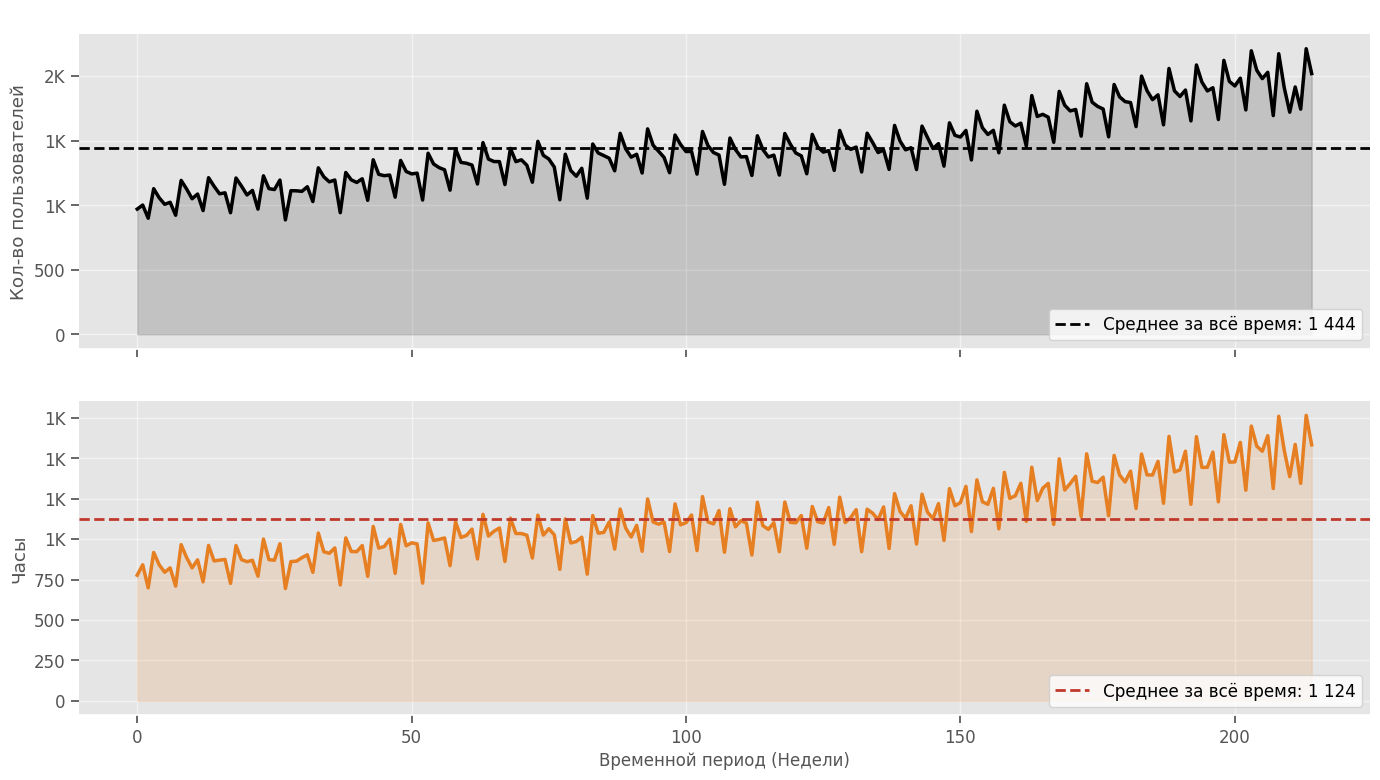

In [18]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import matplotlib.ticker as ticker

# Настройки графиков для красивого отображения
plt.style.use('ggplot')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.1)

MARTS_DIR = Path.cwd() / "data" / "marts"

# Загружаем витрину
df_daily = pl.read_parquet(MARTS_DIR / "mart_daily_metrics.parquet")
pd_daily = df_daily.select(["time_period", "dau", "played_hours"]).to_pandas()

# ---- Агрегация по неделям ----
# Создаем колонку с номером недели
pd_daily['week'] = pd_daily['time_period'] // 7

# Считаем средние дневные показатели внутри каждой недели
pd_weekly = pd_daily.groupby('week').agg({
    'dau': 'mean',
    'played_hours': 'mean'
}).reset_index()

# Создаем фигуру
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ---- График 1: Аудитория (Средний DAU по неделям) ----
color_dau = '#000000'
ax1.plot(pd_weekly["week"], pd_weekly["dau"], color=color_dau, linewidth=2.5)
ax1.fill_between(pd_weekly["week"], pd_weekly["dau"], alpha=0.15, color=color_dau)

# Линия глобального среднего для DAU
mean_dau = pd_weekly["dau"].mean()
ax1.axhline(mean_dau, linestyle='--', linewidth=2, color='#000000',
            label=f'Среднее за всё время: {mean_dau:,.0f}'.replace(',', ' '))
ax1.legend(loc='lower right', frameon=True, facecolor='white',labelcolor='black')


ax1.set_title('Аудитория (Средний DAU по неделям)', loc='left', fontsize=16, fontweight='bold')
ax1.set_ylabel('Кол-во пользователей')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K' if x >= 1000 else int(x)))

# ---- График 2: Вовлеченность (Среднедневные часы по неделям) ----
color_hours = '#E67E22'
ax2.plot(pd_weekly["week"], pd_weekly["played_hours"], color=color_hours, linewidth=2.5)
ax2.fill_between(pd_weekly["week"], pd_weekly["played_hours"], alpha=0.15, color=color_hours)

# Линия глобального среднего для часов
mean_hours = pd_weekly["played_hours"].mean()
ax2.axhline(mean_hours, color='#C0392B', linestyle='--', linewidth=2,
            label=f'Среднее за всё время: {mean_hours:,.0f}'.replace(',', ' '))
ax2.legend(loc='lower right', frameon=True, facecolor='white',labelcolor='black')

ax2.set_title('Вовлеченность (Среднедневные часы прослушивания)', loc='left', fontsize=16)
ax2.set_xlabel('Временной период (Недели)', fontsize=12)
ax2.set_ylabel('Часы')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K' if x >= 1000 else int(x)))

# Делаем графики воздушнее: убираем лишние рамки
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

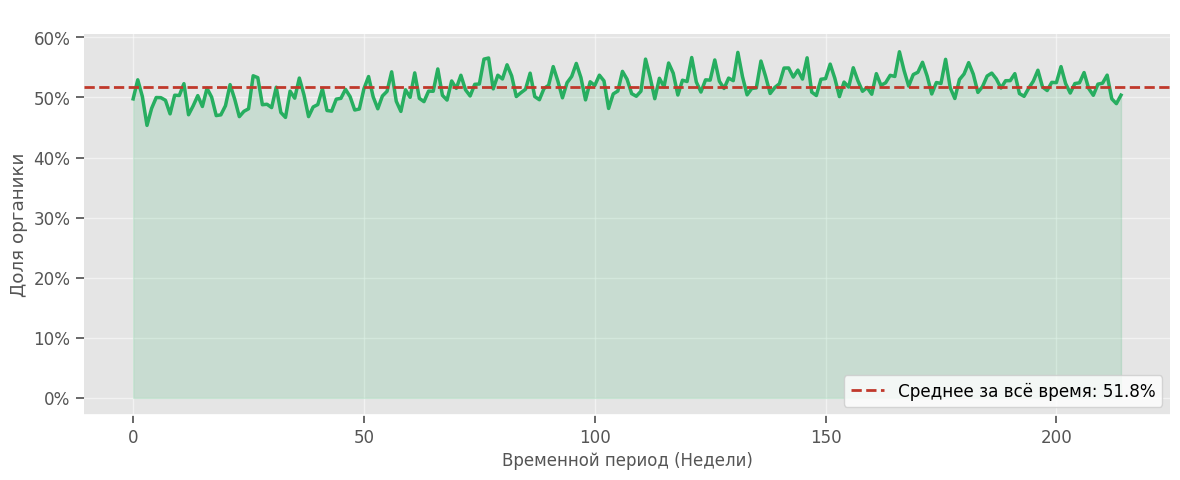

In [19]:
import matplotlib.ticker as ticker

# Переводим в Pandas и сразу агрегируем по неделям
pd_daily = df_daily.select(["time_period", "organic_listen_ratio"]).to_pandas()
pd_daily['week'] = pd_daily['time_period'] // 7
pd_weekly = pd_daily.groupby('week')['organic_listen_ratio'].mean().reset_index()

plt.figure(figsize=(12, 5))
color_org = '#27AE60' # Приятный зеленый

# Сглаженная линия и заливка
sns.lineplot(data=pd_weekly, x="week", y="organic_listen_ratio", color=color_org, linewidth=2.5)
plt.fill_between(pd_weekly["week"], pd_weekly["organic_listen_ratio"], alpha=0.15, color=color_org)

# Линия среднего
mean_org = pd_weekly["organic_listen_ratio"].mean()
plt.axhline(mean_org, color='#C0392B', linestyle='--', linewidth=2,
            label=f'Среднее за всё время: {mean_org:.1%}')

# Оформление
plt.title('Доля органических прослушиваний (в среднем по неделям)', loc='left', fontsize=16, fontweight='bold')
plt.xlabel('Временной период (Недели)', fontsize=12)
plt.ylabel('Доля органики')

# Форматируем ось Y в проценты (например, 50% вместо 0.5)
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

# Читаемая легенда и очистка от лишних рамок
plt.legend(loc='lower right', frameon=True, facecolor='white', labelcolor='black')
plt.gca().spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
plt.show()

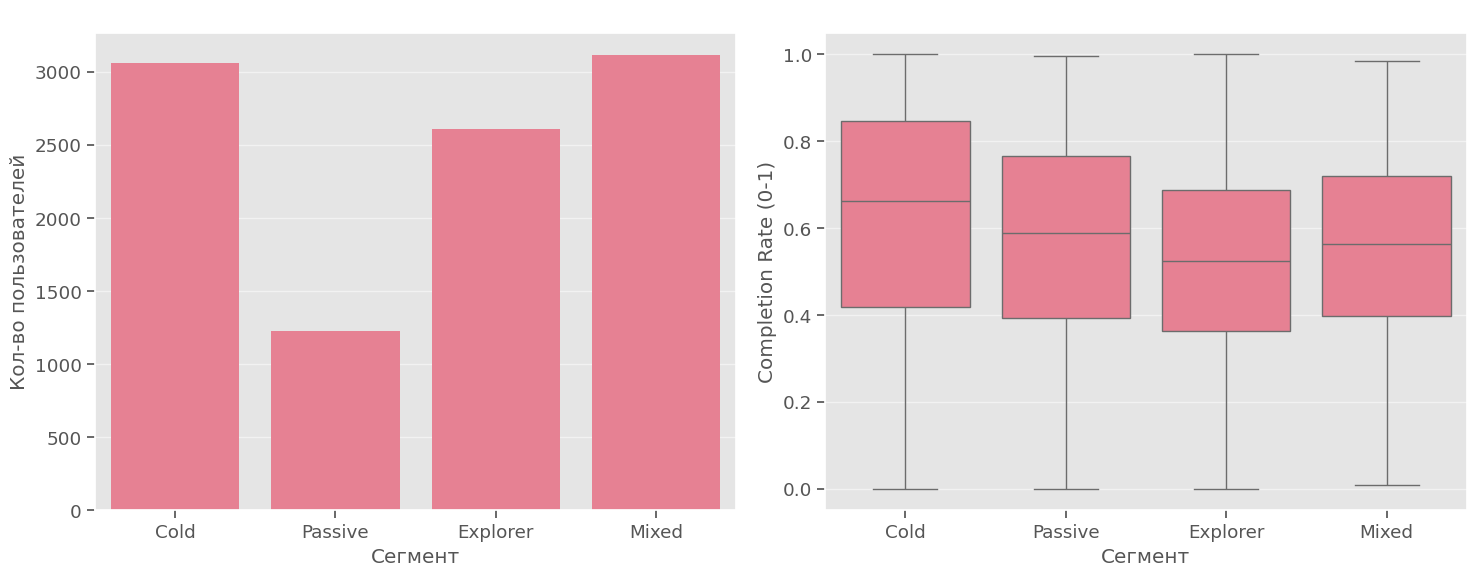

In [7]:
pd_users = df_users.to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Распределение базы по сегментам
sns.countplot(data=pd_users, x='segment', ax=axes[0], order=['Cold', 'Passive', 'Explorer', 'Mixed'])
axes[0].set_title('Размер сегментов пользователей')
axes[0].set_ylabel('Кол-во пользователей')
axes[0].set_xlabel('Сегмент')

# 2. Как сегмент влияет на Completion Rate (Дослушиваемость)
sns.boxplot(data=pd_users, x='segment', y='completion_rate', ax=axes[1], order=['Cold', 'Passive', 'Explorer', 'Mixed'])
axes[1].set_title('Дослушиваемость треков по сегментам')
axes[1].set_ylabel('Completion Rate (0-1)')
axes[1].set_xlabel('Сегмент')

plt.tight_layout()
plt.show()

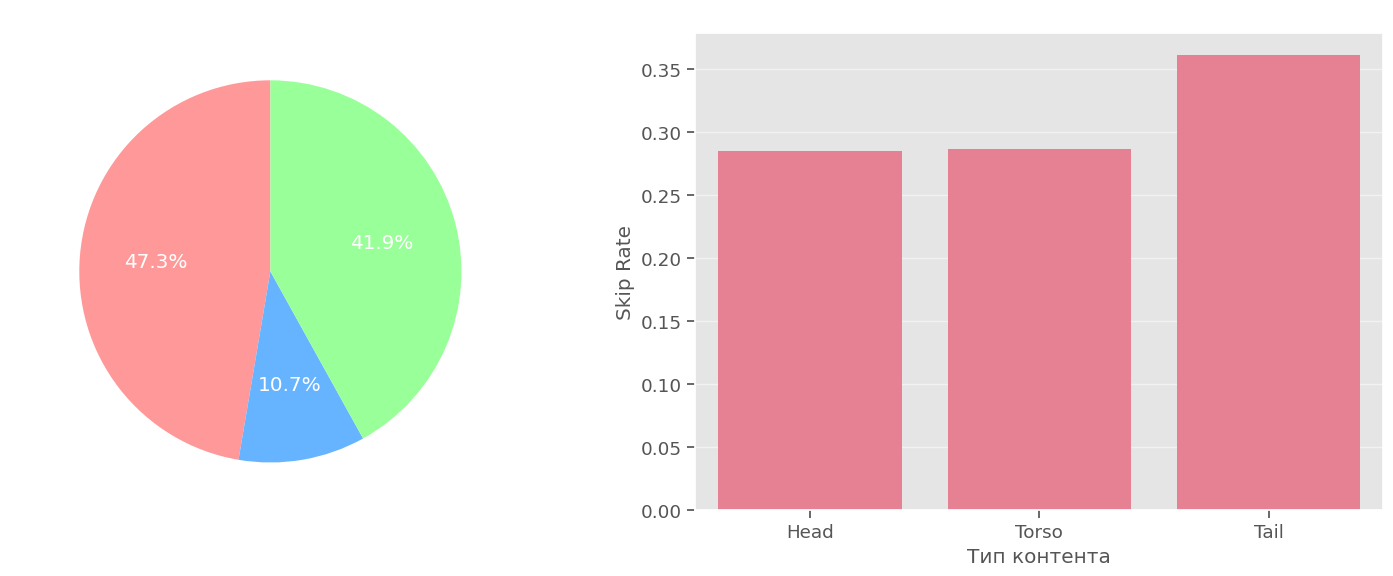

In [8]:
pd_items = df_items.to_pandas()

# Считаем суммарные прослушивания по тирам
tier_stats = pd_items.groupby('content_tier')['listens'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Доля прослушиваний (Пирог)
axes[0].pie(tier_stats['listens'], labels=tier_stats['content_tier'], autopct='%1.1f%%',
            colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
axes[0].set_title('Доля прослушиваний по популярности контента')

# 2. Skip Rate (доля быстрых переключений) по типам контента
sns.barplot(data=pd_items, x='content_tier', y='short_listen_rate', ax=axes[1], errorbar=None,
            order=['Head', 'Torso', 'Tail'])
axes[1].set_title('Доля скипов (<10% трека) по тирам')
axes[1].set_ylabel('Skip Rate')
axes[1].set_xlabel('Тип контента')

plt.tight_layout()
plt.show()